# 05 — LUNA16 ResNet50 (random init) — transfer learning ablation

Identical pipeline to notebook 04 except `pretrained=False`. Pairwise Wilcoxon on per-fold AUC against the pretrained run (in notebook 06) answers research question 1.3 from the diploma.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import yaml
from torchvision import transforms

from utils.seed import set_seed
from utils.models import build_resnet50
from utils.data_luna16 import SlicesDataset
from utils.training import train_dl_cv, save_fold_results
from utils.metrics import aggregate_folds
from utils.stats import format_results_table

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)
set_seed(cfg['seed'])

cache_dir = Path('..') / cfg['data']['cache_dir']
slices = np.load(cache_dir / 'slices_2d.npy')
_labels_df = pd.read_csv(cache_dir / 'labels.csv')
labels = _labels_df['label'].to_numpy().astype(int)
groups = _labels_df['seriesuid'].to_numpy()  # GroupKFold by CT scan

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])
eval_tf = None

dataset = SlicesDataset(slices, labels, transform=eval_tf)
print('slices', slices.shape, 'pos rate:', labels.mean())

slices (1070, 224, 224) pos rate: 0.20093457943925233


In [2]:
def model_fn():
    return build_resnet50(pretrained=False, num_classes=1)

results_dir = Path('..') / cfg['paths']['results']
results_dir.mkdir(parents=True, exist_ok=True)

folds = train_dl_cv(
    dataset=dataset,
    model_fn=model_fn,
    labels=labels,
    n_splits=cfg['cv']['n_splits'],
    seed=cfg['seed'],
    epochs=cfg['dl']['epochs'],
    batch_size=cfg['dl']['batch_size'],
    lr=cfg['dl']['lr'],
    weight_decay=cfg['dl']['weight_decay'],
    patience=cfg['dl']['patience'],
    num_workers=cfg['dl']['num_workers'],
    device='auto',
    augment_train=train_tf,
    augment_eval=eval_tf,
    groups=groups,
    verbose=True,
)

save_fold_results(folds, results_dir / 'luna16_ResNet50_scratch.json')
agg = aggregate_folds([f.metrics_calibrated for f in folds])
format_results_table({'ResNet50_scratch': agg})

[fold 0] train=855 test=215 pos_train=168 pos_test=47
  epoch  1/50 loss=1.1875 val_auc=0.4648
  epoch  2/50 loss=1.1484 val_auc=0.5223
  epoch  3/50 loss=1.1071 val_auc=0.6156
  epoch  4/50 loss=1.0748 val_auc=0.6147
  epoch  5/50 loss=1.1074 val_auc=0.6133
  epoch  6/50 loss=1.0746 val_auc=0.6760
  epoch  7/50 loss=1.0578 val_auc=0.6082
  epoch  8/50 loss=1.0454 val_auc=0.6228
  epoch  9/50 loss=1.1469 val_auc=0.6094
  epoch 10/50 loss=1.0395 val_auc=0.6292
  epoch 11/50 loss=1.0549 val_auc=0.6921
  epoch 12/50 loss=1.0330 val_auc=0.6505
  epoch 13/50 loss=1.0488 val_auc=0.7012
  epoch 14/50 loss=0.9705 val_auc=0.7044
  epoch 15/50 loss=1.0059 val_auc=0.6703
  epoch 16/50 loss=0.9950 val_auc=0.6672
  epoch 17/50 loss=0.9234 val_auc=0.6901
  epoch 18/50 loss=0.9039 val_auc=0.7470
  epoch 19/50 loss=0.9224 val_auc=0.6765
  epoch 20/50 loss=0.8957 val_auc=0.6911
  epoch 21/50 loss=0.8547 val_auc=0.7223
  epoch 22/50 loss=0.8012 val_auc=0.7283
  epoch 23/50 loss=0.8284 val_auc=0.7620
  e

,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,auc_roc,pr_auc
model,,,,,,,,
ResNet50_scratch,0.730 ± 0.063,0.573 ± 0.150,0.768 ± 0.069,0.390 ± 0.105,0.460 ± 0.113,0.671 ± 0.083,0.745 ± 0.083,0.467 ± 0.137


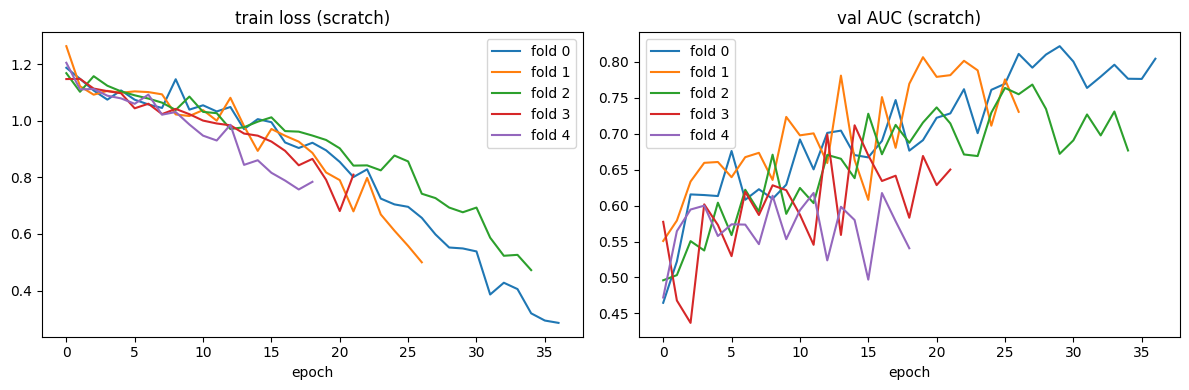

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for f in folds:
    if f.train_history is None:
        continue
    axes[0].plot(f.train_history['loss'], label=f'fold {f.fold}')
    axes[1].plot(f.train_history['auc'], label=f'fold {f.fold}')
axes[0].set_title('train loss (scratch)'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('val AUC (scratch)'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()